# CompileML visualization gallery

Notebooks 01 and 03 show the plots in context, using defaults. This one is
the **reference**: what every option does, rendered.

Everything here draws `decide()` payloads — the deployed integers — and never
recomputes the model. A chart cannot disagree with the decision it depicts.

> **Not executed in CI.** The APIs shown are covered by `tests/test_viz.py`;
> this notebook ships committed outputs as rendered evidence. Re-run it
> yourself after changing anything in `compileml.viz`.

```
pip install compileml[viz]
```

## Setup

One small artifact and one explained sample, reused throughout.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier

from compileml.artifact import build_artifact
from compileml.bands import monotone_quantile_bands
from compileml.compile import train_whitebox
from compileml.runtime import decide

warnings.filterwarnings("ignore")
rng = np.random.default_rng(7)

FEATURES = [
    "UTILIZATION", "PAYMENT_RATIO", "BILLS_PAID_LATE", "MONTHS_ON_BOOK",
    "N_CREDIT_LINES", "INQUIRIES_6M", "BALANCE_TO_LIMIT", "INCOME_PROXY",
]
REASONS = {
    "UTILIZATION":      {"code": "HIGH_UTILIZATION",  "negative": "Utilization is high.",        "positive": "Utilization is well managed."},
    "PAYMENT_RATIO":    {"code": "PAYMENT_LEVEL",     "negative": "Payments cover little.",       "positive": "Payments cover a healthy share."},
    "BILLS_PAID_LATE":  {"code": "LATE_PAYMENTS",     "negative": "Recent payments were late.",   "positive": "Consistent on-time history."},
    "MONTHS_ON_BOOK":   {"code": "CREDIT_AGE",        "negative": "Short account history.",       "positive": "Long, established history."},
    "N_CREDIT_LINES":   {"code": "OPEN_LINES",        "negative": "Many open lines.",             "positive": "Moderate number of lines."},
    "INQUIRIES_6M":     {"code": "RECENT_INQUIRIES",  "negative": "Several recent applications.", "positive": "Few recent applications."},
    "BALANCE_TO_LIMIT": {"code": "BALANCE_PRESSURE",  "negative": "Balances press on limits.",    "positive": "Comfortable balances."},
    "INCOME_PROXY":     {"code": "CAPACITY",          "negative": "Limited payment capacity.",    "positive": "Strong payment capacity."},
}

n = 6000
X = rng.standard_normal((n, len(FEATURES)))
logit = 1.4 * X[:, 0] - 1.1 * X[:, 1] + 0.9 * X[:, 2] + 0.6 * X[:, 6] * X[:, 0] - 0.4 * X[:, 7]
y = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)

teacher = GradientBoostingClassifier(n_estimators=80, max_depth=4, random_state=7).fit(X, y)
whitebox, _ = train_whitebox(X, teacher.predict_proba(X)[:, 1], n_estimators=60, random_state=7)
latent = np.clip(whitebox.predict(X), 0, 1)

artifact = build_artifact(
    whitebox, FEATURES, np.median(X, axis=0),
    monotone_quantile_bands(latent, y, n_bands=8),
    calibration_latent=latent, calibration_y=y, reasons=REASONS,
)

# ONE explained sample, reused by every population figure below. Explaining
# 150 rows at 8 features costs ~0.2 s — the plots themselves are free.
# include_contributions=True adds the per-feature vector the waterfall needs;
# the driver plots need only the reason blocks that explain=True already gives.
SAMPLE_N = 150
sample = [
    decide(artifact, [float(v) for v in r], include_contributions=True)
    for r in X[:SAMPLE_N]
]
y_sample = y[:SAMPLE_N]
values = [dict(zip(FEATURES, row)) for row in X[:SAMPLE_N]]

print(f"artifact {artifact['artifact_hash'][:16]}…  ·  {len(sample)} explained decisions ready")

artifact 46d196e98753c7aa…  ·  150 explained decisions ready


---
## 1. Anatomy of a waterfall

Each bar is a single 7-point polygon — body and arrow head in one path, so the
head can never detach or mis-scale. The head is an *adaptive* fraction of the
bar: short bars get proportionally chunkier heads so they stay recognisable,
and every head carries a barb slightly wider than its shaft.

Bars run baseline → contributions → score, largest impact first.

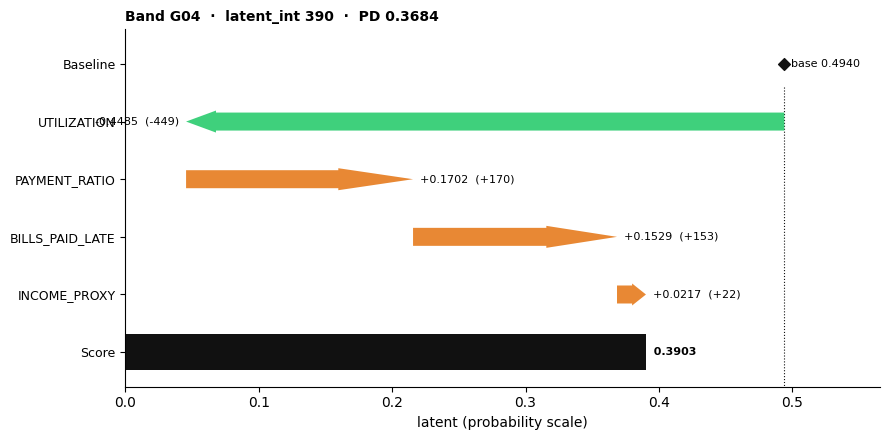

In [2]:
from compileml.viz import waterfall

# Pick the decision with the widest spread of impacts — it exercises the
# adaptive head geometry across large and small bars at once.
def spread(d):
    v = [abs(c["impact_half_micro"]) for c in d["contributions"]]
    return max(v) - min(v)

showcase = max(sample, key=spread)
fig, ax = waterfall(showcase)
plt.show()

### Truncation still balances

`max_features` limits the rows. Everything omitted collapses into one grey
**remainder** bar — so the arithmetic still closes exactly, no matter how few
rows you show.

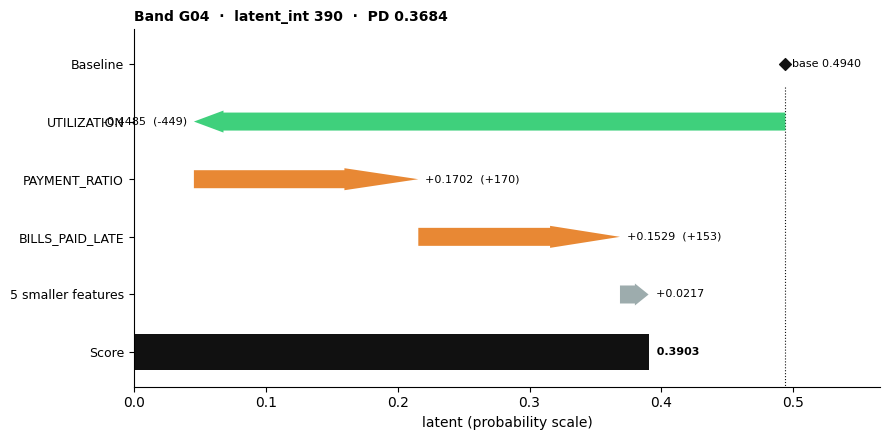

2*(score - baseline) = -207418
sum of drawn bars    = -207418
labels: ['UTILIZATION', 'PAYMENT_RATIO', 'BILLS_PAID_LATE', '5 smaller features']


In [3]:
fig, ax = waterfall(showcase, max_features=3)
plt.show()

from compileml.viz._data import waterfall_segments

segs = waterfall_segments(showcase, max_features=3)
lhs = 2 * (segs["raw_micro"] - segs["baseline_micro"])
print(f"2*(score - baseline) = {lhs}")
print(f"sum of drawn bars    = {sum(s['half_micro'] for s in segs['segments'])}")
print("labels:", [s["label"] for s in segs["segments"]])

---
## 2. Two edge cases worth seeing

**Sub-pixel bars.** Below ~0.3 px a triangle renders as a smear, so those
contributions draw as a short vertical tick instead — visible, honest, not
pretending to be an arrow.

**Interaction residual.** At whitebox depth ≤ 2 the pairwise decomposition is
complete and the residual is exactly zero. Compile deeper and it is not — so
the leftover is drawn as its own purple bar rather than being quietly folded
into a feature that did not earn it.

exact_attribution: False
residual (half-micro): -35530


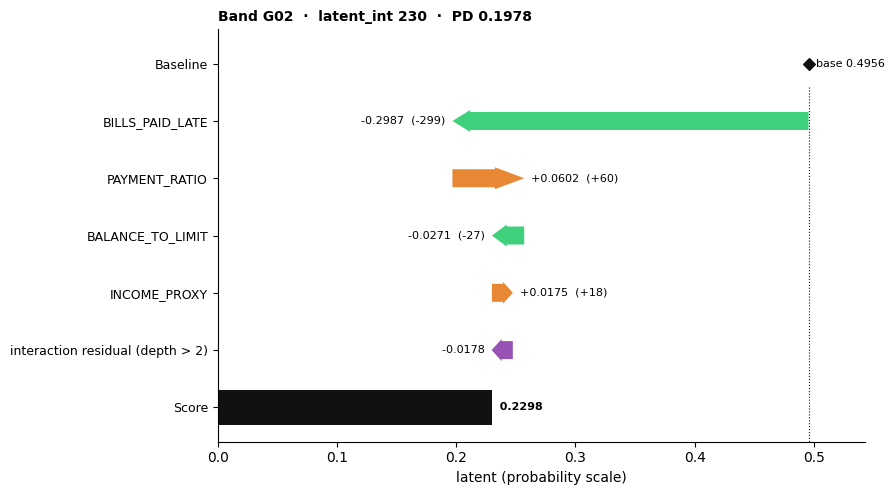

In [4]:
deep, _ = train_whitebox(
    X, teacher.predict_proba(X)[:, 1], n_estimators=40, max_depth=3, random_state=7
)
deep_latent = np.clip(deep.predict(X), 0, 1)
deep_artifact = build_artifact(
    deep, FEATURES, np.median(X, axis=0),
    monotone_quantile_bands(deep_latent, y, n_bands=8),
    calibration_latent=deep_latent, calibration_y=y, reasons=REASONS,
)
print("exact_attribution:", deep_artifact["runtime"]["exact_attribution"])

deep_decision = decide(deep_artifact, [float(v) for v in X[3]], include_contributions=True)
print("residual (half-micro):", deep_decision["attribution_residual_half_micro"])

fig, ax = waterfall(deep_decision)
plt.show()

---
## 3. The same waterfall, without matplotlib

`waterfall_svg()` renders from the standard library alone — the payload is
plain integers, so no plotting stack is required. Output is deterministic:
same payload, same bytes. The image on the project README is this function's
output.

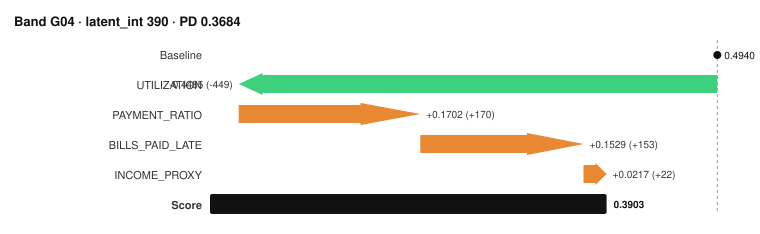

2,085 bytes · deterministic: True


In [5]:
from IPython.display import SVG, display

from compileml.viz import waterfall_svg

svg = waterfall_svg(showcase, max_features=6)
display(SVG(svg))
print(f"{len(svg):,} bytes · deterministic: {waterfall_svg(showcase, max_features=6) == svg}")

---
## 4. Decision drivers: what the colours mean

One point per (decision, reason). Points are labelled by **reason code**,
ranked by mean absolute impact with the biggest driver on top, and given a
micro-jitter *within* each identical-value pile so discrete scores do not
stack into a single vertical line. The black tick is the mean impact.

`color_by` picks the encoding:

* `"outcome"` — observed repayment vs default (needs `y`)
* `"impact"` — risk-decreasing vs risk-increasing
* `"auto"` — outcome when `y` is supplied, impact otherwise

Risk-increasing points are drawn slightly larger, more opaque, and on top:
the adverse side of a decision should not hide behind the favourable side.

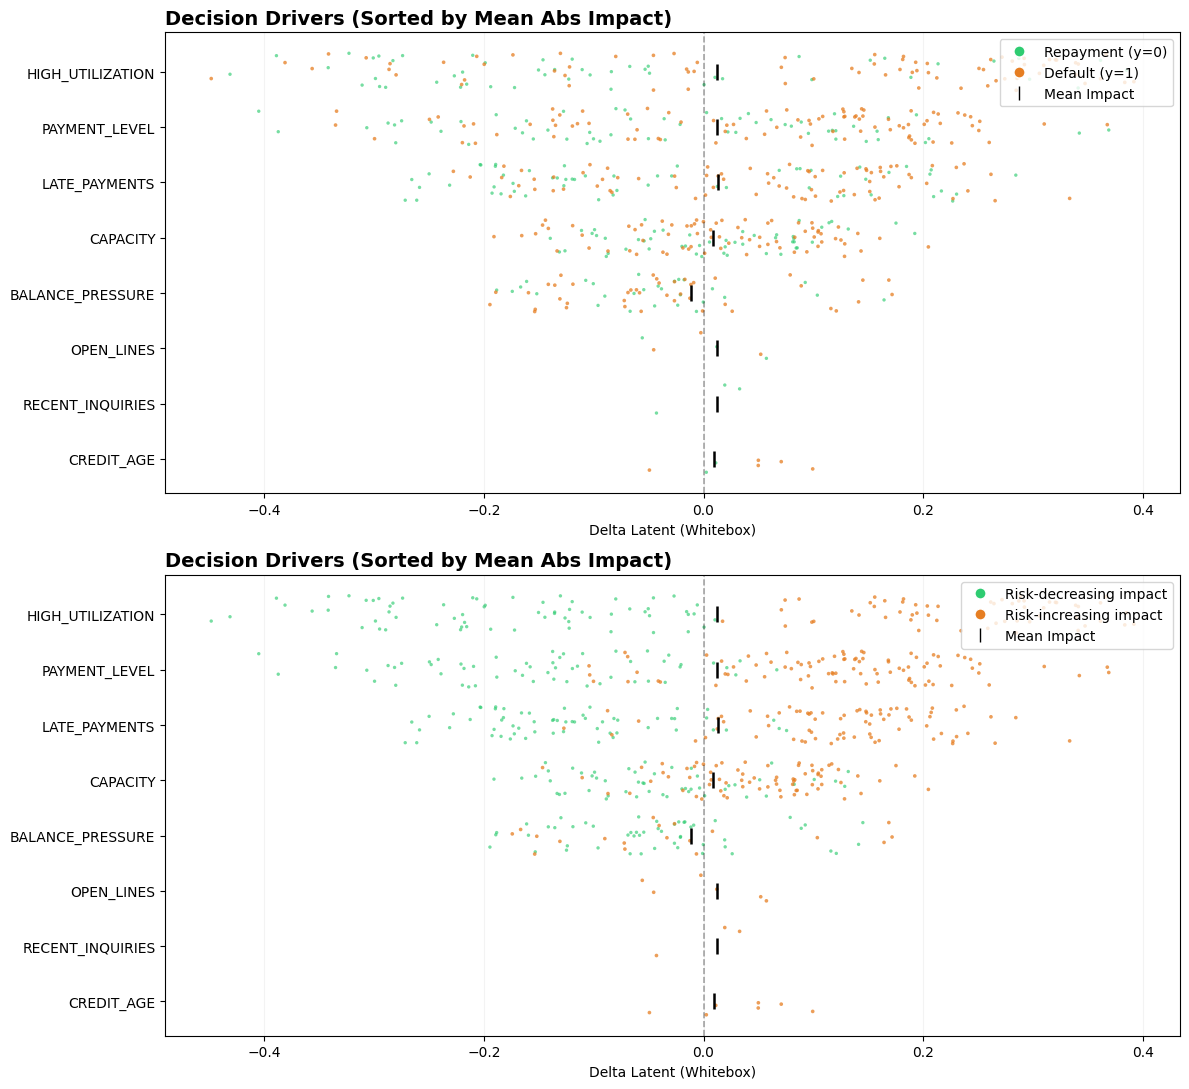

In [6]:
from compileml.viz import decision_drivers

fig, axes = plt.subplots(2, 1, figsize=(12, 11))
decision_drivers(sample, y=y_sample, color_by="outcome", top_codes=8, ax=axes[0])
decision_drivers(sample, color_by="impact", top_codes=8, ax=axes[1])
plt.tight_layout()
plt.show()

### Encoding the feature value too

`value_color=True` shades each point by where that applicant's feature value
falls in the population (dark = low, bright = high), which is how you read
*direction*: high utilization pushing risk up looks different from low
utilization pulling it down. `value_alpha=True` does the same through opacity
when you want to keep colour for outcome.

Both need `values` — one `{feature: value}` dict per decision.

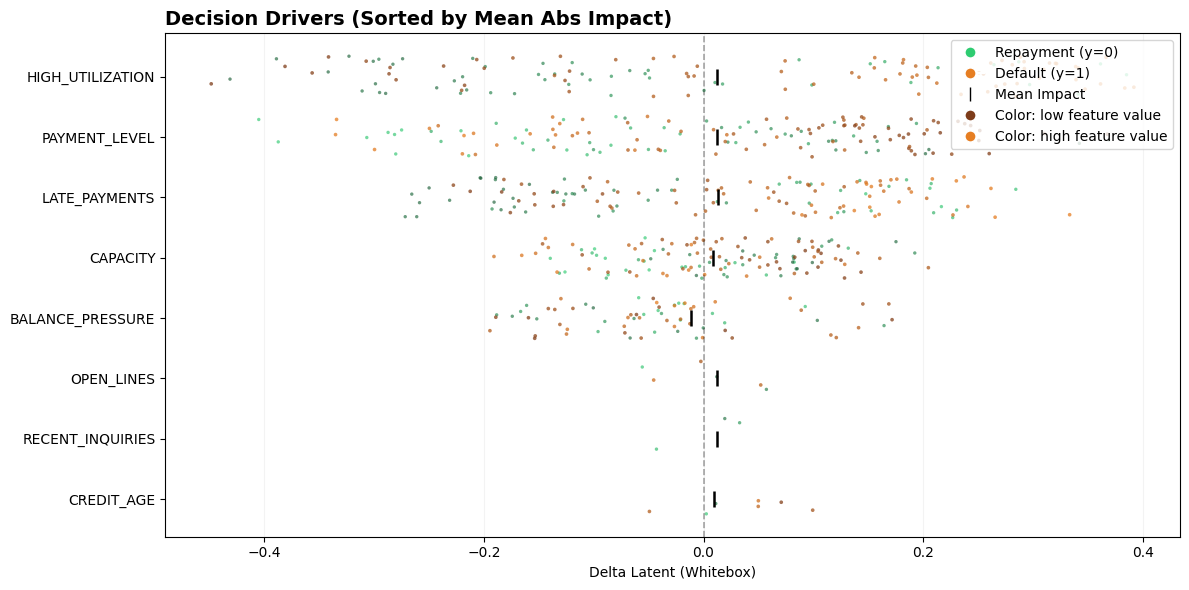

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
decision_drivers(
    sample, y=y_sample, values=values, value_color=True, top_codes=8, ax=ax
)
plt.show()

### Ranking by something other than the mean

`sort_metric` chooses what "biggest driver" means: `"mean"` absolute impact
(default), `"sum"` (weights how *often* a reason fires), or `"max"` (surfaces
rare but extreme drivers).

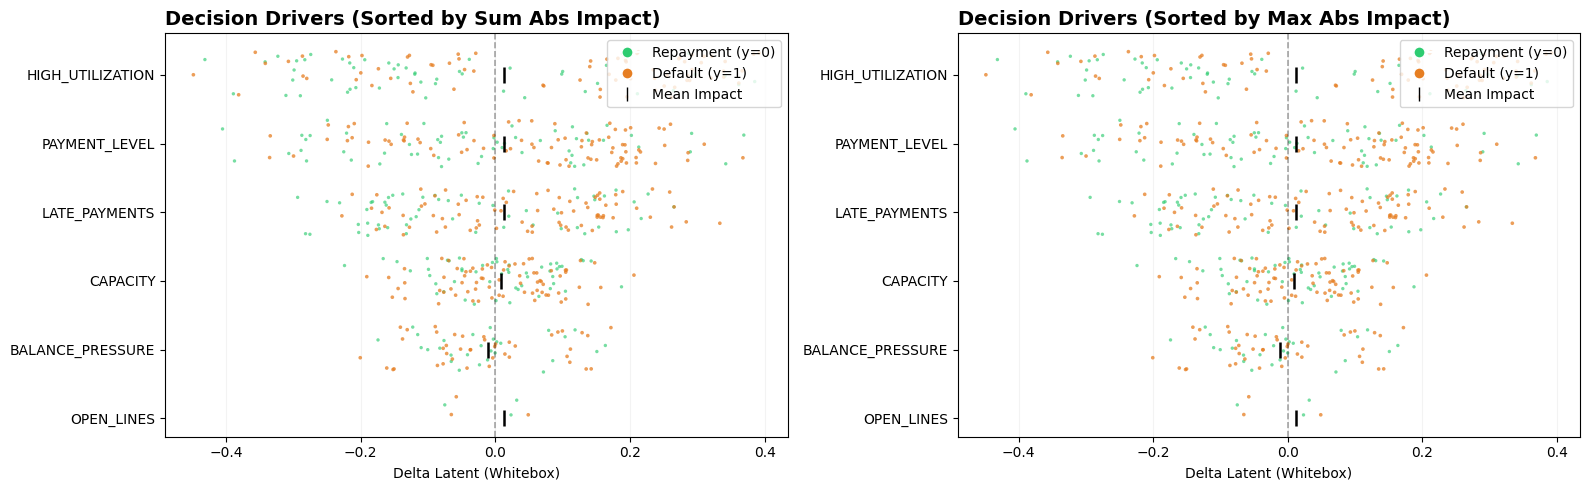

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
decision_drivers(sample, y=y_sample, sort_metric="sum", top_codes=6, ax=axes[0])
decision_drivers(sample, y=y_sample, sort_metric="max", top_codes=6, ax=axes[1])
plt.tight_layout()
plt.show()

---
## 5. Drivers per band

The same beeswarm, faceted by risk band, each panel ranking its own top
reasons. This is the segment-level diagnostic: what separates a G02
population from a G07 one.

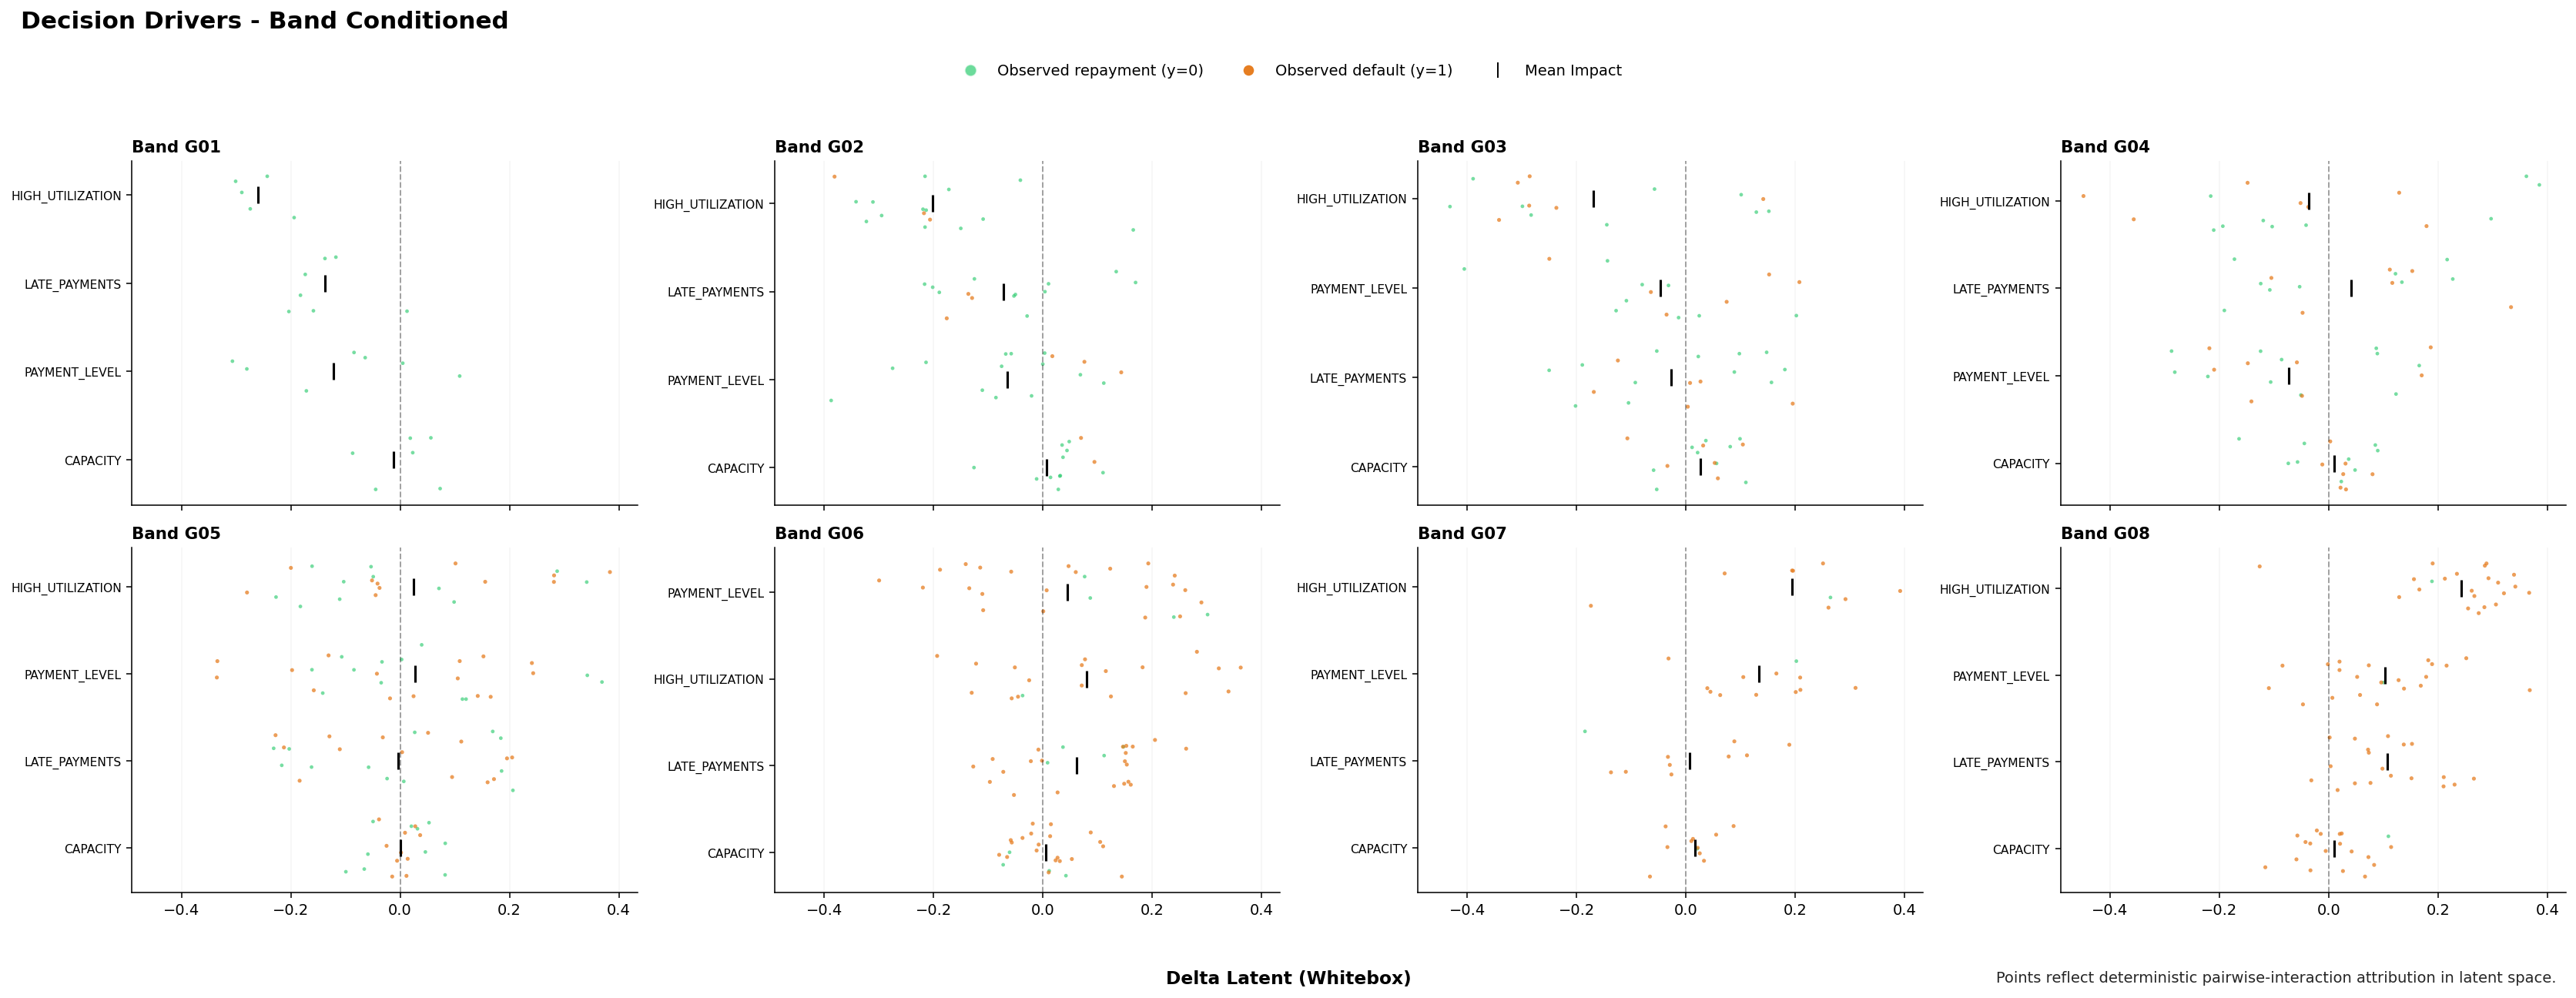

In [9]:
from compileml.viz import band_conditioned_decision_drivers

fig, axes = band_conditioned_decision_drivers(sample, y=y_sample, top_codes=4, cols=4)
plt.show()

`target_band` focuses a single band — useful when a policy question is about
one segment, such as the applicants sitting just above a cutoff.

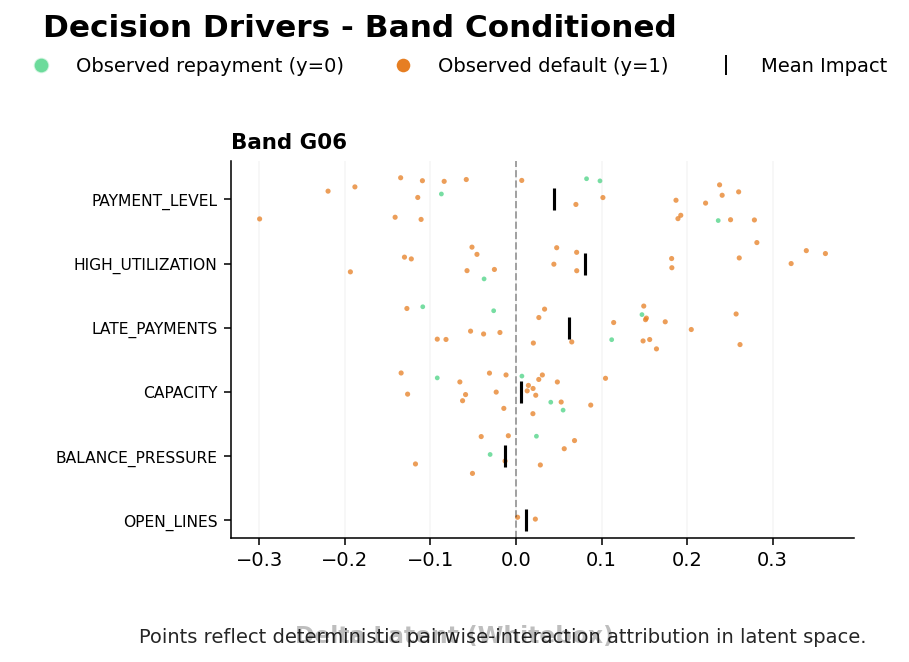

In [10]:
busiest = max({d["band"] for d in sample}, key=lambda b: sum(d["band"] == b for d in sample))
fig, axes = band_conditioned_decision_drivers(
    sample, y=y_sample, target_band=busiest, top_codes=6, cols=1
)
plt.show()

---
## 6. The band ladder

Observed bad rate per band — the monotonicity picture a committee asks for.
This one needs no attribution at all, so cheap `explain=False` payloads are
enough and the whole portfolio can go in.

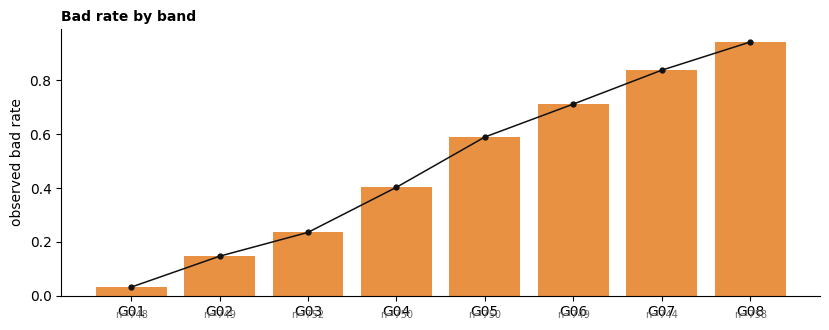

In [11]:
from compileml.viz import band_ladder

score_only = [decide(artifact, [float(v) for v in r], explain=False) for r in X]
fig, ax = band_ladder(score_only, y)
plt.show()

---
## 7. Making it yours

Every renderer takes `labels` (display names), `colors` (institutional
palette), and — for the single-axes plots — an `ax` to compose into your own
figure.

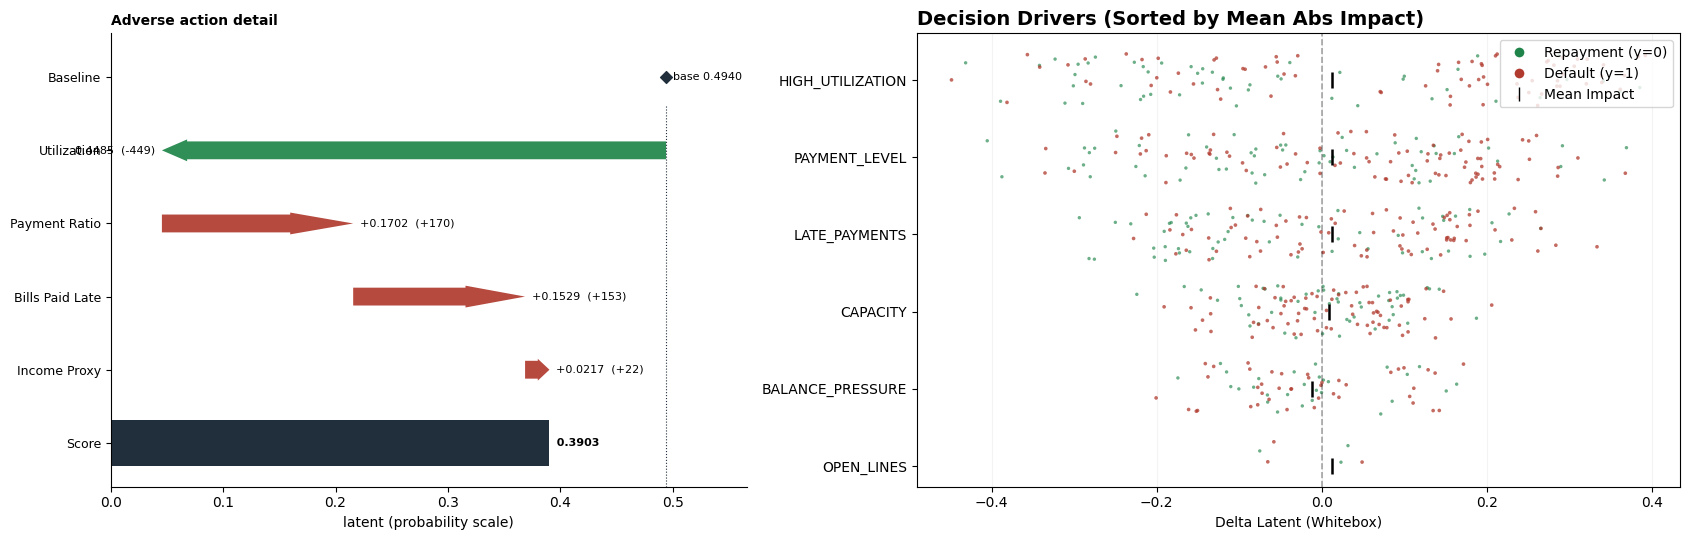

In [12]:
house_style = {
    "up": "#B03A2E", "down": "#1E8449", "base": "#212F3D", "remainder": "#AEB6BF",
    "good": "#1E8449", "bad": "#B03A2E", "neutral": "#5D6D7E",
}
display_names = {f: f.replace("_", " ").title() for f in FEATURES}

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5), gridspec_kw={"width_ratios": [1, 1.2]})
waterfall(showcase, max_features=5, labels=display_names, colors=house_style, ax=axes[0],
          title="Adverse action detail")
decision_drivers(sample, y=y_sample, colors=house_style, top_codes=6, ax=axes[1])
plt.tight_layout()
plt.show()

---
## Where to go next

* [Visualization how-to](../docs/howto/visualize.md) — the same API in prose
* [Exact attribution](../docs/concepts/attribution.md) — what the numbers behind these bars mean
* [Reason codes](../docs/howto/reason-codes.md) — the dictionary that supplies the labels above